# TP2 - Aprendizaje Supervisado (version Python / scikit-learn)

Replica del flujo hecho en R, como referencia para usar el mismo analisis en ambos lenguajes.

**Importante - los resultados no son identicos a los de R:**
- El RNG de R y el de scikit-learn son distintos: la particion train/test con la misma semilla **no** da las mismas filas.
- `rpart` (R) y el arbol de sklearn usan CART pero con podas/defaults distintos: el arbol puede quedar con otra forma.
- `nnet` (R) y `MLPClassifier` (sklearn) son implementaciones diferentes: el accuracy de la red puede variar.

Mismo flujo y misma logica. Los numeros van a ser parecidos pero no clonados.

*Nota:* a diferencia de `nnet`, `MLPClassifier` suele rendir bastante mejor con las variables escaladas (StandardScaler). Aca se deja sin escalar para mantener el paralelo 1 a 1 con R; si la red converge mal, agregar el escalado es el primer paso.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

DNI = 42835505   # se usa como semilla

## Parte A - Preprocesamiento de los datos

In [2]:
# Carga del dataset de granos de trigo
base = pd.read_csv("seeds_dataset.txt", sep=r"\s+", header=None)
base.head()

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [3]:
# Renombrado de las variables segun los atributos de los granos
base.columns = ["Area", "Perimetro", "Compactitud", "Largo",
                "Ancho", "Asimetria", "Division", "Tipo"]
base.head()

,Area,Perimetro,Compactitud,Largo,Ancho,Asimetria,Division,Tipo
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [4]:
# Transformacion de la variable Tipo a categorica
base["Tipo"] = pd.Categorical(
    base["Tipo"].map({1: "kama", 2: "rosa", 3: "canadian"}),
    categories=["kama", "rosa", "canadian"]
)
base.head()

,Area,Perimetro,Compactitud,Largo,Ancho,Asimetria,Division,Tipo
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,kama


## Parte B - Analisis Exploratorio de Datos

In [5]:
# Cantidad de semillas en total y por variedad
print(base.shape)
base["Tipo"].value_counts()

(210, 8)


Tipo
kama        70
rosa        70
canadian    70
Name: count, dtype: int64

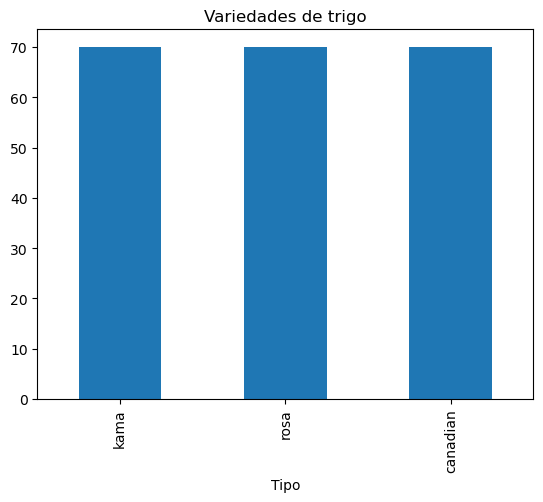

In [6]:
# Grafico de barras de la variable a predecir Tipo
base["Tipo"].value_counts().reindex(["kama", "rosa", "canadian"]).plot(
    kind="bar", title="Variedades de trigo")
plt.show()

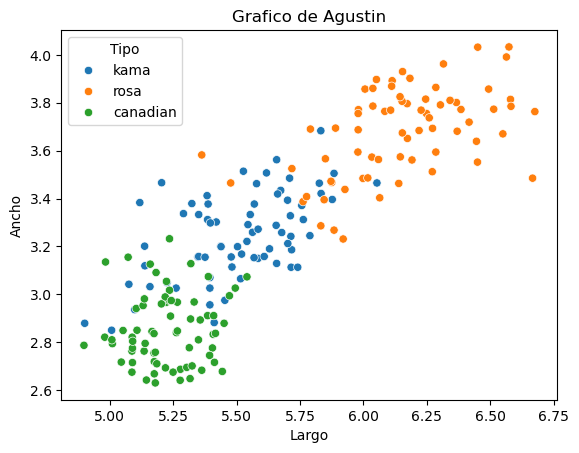

In [7]:
# Grafico de dispersion entre Largo y Ancho, coloreado por Tipo
sns.scatterplot(data=base, x="Largo", y="Ancho", hue="Tipo")
plt.title("Grafico de Agustin")
plt.show()

In [8]:
# Registro correspondiente a los 2 ultimos digitos del DNI (05)
# R usa indice base 1: base[5, ]  ->  en Python (base 0) es iloc[4]
trigo = base.iloc[[4]]
trigo

,Area,Perimetro,Compactitud,Largo,Ancho,Asimetria,Division,Tipo
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,kama


## Parte C - Conjuntos

In [9]:
# Particion en entrenamiento (75%) y testeo (25%), estratificada por Tipo
# DNI termina en 5 -> p=0.75 -> (test_size=0.25)
entreno, testeo = train_test_split(
    base, test_size=0.25, stratify=base["Tipo"], random_state=DNI)

In [10]:
# head y summary (describe) de cada conjunto
display(entreno.head())
display(entreno.describe())
display(testeo.head())
display(testeo.describe())

,Area,Perimetro,Compactitud,Largo,Ancho,Asimetria,Division,Tipo
98,18.17,16.26,0.8637,6.271,3.512,2.853,6.273,rosa
77,20.71,17.23,0.8763,6.579,3.814,4.451,6.451,rosa
199,12.76,13.38,0.8964,5.073,3.155,2.828,4.830,canadian
155,11.19,13.05,0.8253,5.250,2.675,5.813,5.219,canadian
67,14.01,14.29,0.8625,5.609,3.158,2.217,5.132,kama


,Area,Perimetro,Compactitud,Largo,Ancho,Asimetria,Division
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,14.859108,14.573057,0.869924,5.640312,3.257777,3.799720,5.419108
std,2.939004,1.320172,0.024090,0.450407,0.380628,1.508908,0.496065
min,10.590000,12.410000,0.808100,4.899000,2.641000,0.765100,4.519000
25%,12.300000,13.460000,0.856400,5.267000,2.941000,2.699000,5.056000
50%,14.340000,14.290000,0.871700,5.541000,3.231000,3.639000,5.270000
75%,17.320000,15.730000,0.887400,5.998000,3.561000,4.773000,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


,Area,Perimetro,Compactitud,Largo,Ancho,Asimetria,Division,Tipo
182,12.19,13.36,0.8579,5.240,2.909,4.857,5.158,canadian
139,16.23,15.18,0.8850,5.872,3.472,3.769,5.922,rosa
45,13.80,14.04,0.8794,5.376,3.155,1.560,4.961,kama
50,14.43,14.40,0.8751,5.585,3.272,3.975,5.144,kama
112,19.13,16.31,0.9035,6.183,3.902,2.109,5.924,rosa


,Area,Perimetro,Compactitud,Largo,Ancho,Asimetria,Division
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,14.813208,14.518491,0.874181,5.593642,3.261057,3.405398,5.375377
std,2.848398,1.274393,0.022121,0.422772,0.372526,1.461958,0.480789
min,10.820000,12.800000,0.825600,4.984000,2.630000,0.855100,4.605000
25%,12.210000,13.360000,0.857900,5.224000,2.968000,2.188000,5.001000
50%,14.430000,14.400000,0.878300,5.520000,3.272000,3.332000,5.158000
75%,16.630000,15.460000,0.889400,5.979000,3.563000,4.462000,5.877000
max,20.200000,16.990000,0.910800,6.581000,3.902000,6.685000,6.449000


In [11]:
# Cantidad de registros por variedad en cada conjunto
print(base["Tipo"].value_counts())
print(entreno["Tipo"].value_counts())
print(testeo["Tipo"].value_counts())

Tipo
kama        70
rosa        70
canadian    70
Name: count, dtype: int64
Tipo
kama        53
rosa        52
canadian    52
Name: count, dtype: int64
Tipo
rosa        18
canadian    18
kama        17
Name: count, dtype: int64


## Parte D - Arbol de Decision

In [14]:
# Separacion de variables predictoras (X) y objetivo (y)
X_entreno = entreno.drop(columns="Tipo")
y_entreno = entreno["Tipo"]
X_testeo = testeo.drop(columns="Tipo")
y_testeo = testeo["Tipo"]

# Creacion del Arbol de Decision
arbol = DecisionTreeClassifier(random_state=DNI) # primero se crea el arbol vacio
arbol.fit(X_entreno, y_entreno)                  # Se entrena con los datos

# Estructura del arbol en texto (equivalente a print(arbol) en R)
print(export_text(arbol, feature_names=list(X_entreno.columns)))

|--- Division <= 5.58
|   |--- Area <= 12.71
|   |   |--- Division <= 4.75
|   |   |   |--- class: kama
|   |   |--- Division >  4.75
|   |   |   |--- Asimetria <= 1.81
|   |   |   |   |--- class: kama
|   |   |   |--- Asimetria >  1.81
|   |   |   |   |--- class: canadian
|   |--- Area >  12.71
|   |   |--- Asimetria <= 5.27
|   |   |   |--- Perimetro <= 13.44
|   |   |   |   |--- class: canadian
|   |   |   |--- Perimetro >  13.44
|   |   |   |   |--- Asimetria <= 4.61
|   |   |   |   |   |--- Division <= 5.42
|   |   |   |   |   |   |--- class: kama
|   |   |   |   |   |--- Division >  5.42
|   |   |   |   |   |   |--- Largo <= 5.59
|   |   |   |   |   |   |   |--- class: rosa
|   |   |   |   |   |   |--- Largo >  5.59
|   |   |   |   |   |   |   |--- class: kama
|   |   |   |   |--- Asimetria >  4.61
|   |   |   |   |   |--- Perimetro <= 13.80
|   |   |   |   |   |   |--- class: canadian
|   |   |   |   |   |--- Perimetro >  13.80
|   |   |   |   |   |   |--- class: kama
|   |   |-

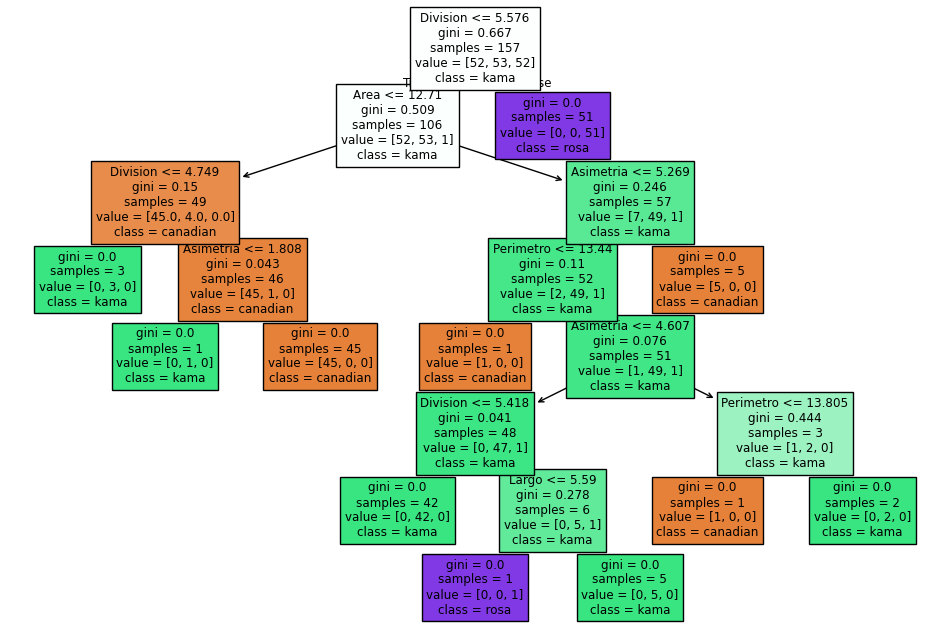

In [16]:
# Grafico del Arbol de Decision
plt.figure(figsize=(12, 8))
plot_tree(arbol, feature_names=list(X_entreno.columns),
          class_names=list(arbol.classes_), filled=True)
plt.show() # Aclaración: este AdD esta sin podar por defecto en Python, se puede mejorar

In [17]:
# Matriz de confusion sobre el conjunto de testeo
pred = arbol.predict(X_testeo)
print(confusion_matrix(y_testeo, pred, labels=["kama", "rosa", "canadian"]))
print("Accuracy:", accuracy_score(y_testeo, pred))
print(classification_report(y_testeo, pred))

[[14  1  2]
 [ 1 17  0]
 [ 2  0 16]]
Accuracy: 0.8867924528301887
              precision    recall  f1-score   support

    canadian       0.89      0.89      0.89        18
        kama       0.82      0.82      0.82        17
        rosa       0.94      0.94      0.94        18

    accuracy                           0.89        53
   macro avg       0.89      0.89      0.89        53
weighted avg       0.89      0.89      0.89        53



In [18]:
# Verificacion: aciertos (diagonal) sobre total de testeo = accuracy
cm = confusion_matrix(y_testeo, pred)
print(np.trace(cm) / cm.sum())

0.8867924528301887


In [19]:
# Prediccion de la semilla correspondiente al DNI (fila 5)
arbol.predict(trigo.drop(columns="Tipo"))

array(['kama'], dtype=object)

## Parte E - Red Neuronal

In [20]:
# Red Neuronal con 25 neuronas en la capa oculta, maxit=10000
red = MLPClassifier(hidden_layer_sizes=(25,), max_iter=10000,
                    random_state=DNI)
red.fit(X_entreno, y_entreno)

MLPClassifier(hidden_layer_sizes=(25,), max_iter=10000, random_state=42835505)

In [21]:
# Informacion de la red (equivalente a print(red))
print("Arquitectura:",
      [X_entreno.shape[1]] + list(red.hidden_layer_sizes) + [len(red.classes_)])
print("Iteraciones:", red.n_iter_)
print("Loss final:", red.loss_)

Arquitectura: [7, 25, 3]
Iteraciones: 1167
Loss final: 0.13581129331398453


In [22]:
# Matriz de confusion sobre el conjunto de testeo
pred2 = red.predict(X_testeo)
print(confusion_matrix(y_testeo, pred2, labels=["kama", "rosa", "canadian"]))
print("Accuracy:", accuracy_score(y_testeo, pred2))
print(classification_report(y_testeo, pred2))

[[15  1  1]
 [ 1 17  0]
 [ 2  0 16]]
Accuracy: 0.9056603773584906
              precision    recall  f1-score   support

    canadian       0.94      0.89      0.91        18
        kama       0.83      0.88      0.86        17
        rosa       0.94      0.94      0.94        18

    accuracy                           0.91        53
   macro avg       0.91      0.91      0.91        53
weighted avg       0.91      0.91      0.91        53



In [23]:
# Prediccion de la semilla correspondiente al DNI (fila 5)
red.predict(trigo.drop(columns="Tipo"))

array(['kama'], dtype='<U8')